In [159]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [160]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [161]:
random.randint(140, 195)

176

In [162]:
data = []
for i in range(50):
    # 여자 데이터(몸무게와 키) 추가
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터(몸무게와 키) 추가
    data.append([random.randint(60, 95), random.randint(160, 195)])

In [163]:
print('여자 몸무게(X축) : ',[female[0] for female in data[::2]])
print('여자 키(Y축) : ',[female[1] for female in data[::2]])

print('남자 몸무게(X축) : ',[male[0] for male in data[1::2]])
print('남자 키(Y축) : ',[male[1] for male in data[1::2]])

여자 몸무게(X축) :  [45, 65, 52, 69, 49, 57, 57, 48, 53, 67, 44, 62, 45, 66, 58, 47, 56, 70, 65, 67, 53, 54, 48, 63, 48, 45, 58, 49, 60, 40, 54, 54, 57, 68, 70, 54, 48, 45, 52, 59, 57, 51, 41, 47, 59, 57, 58, 65, 53, 67]
여자 키(Y축) :  [157, 156, 167, 150, 145, 159, 142, 153, 156, 150, 148, 158, 147, 153, 143, 152, 160, 142, 153, 141, 157, 168, 163, 161, 163, 141, 167, 159, 148, 149, 147, 149, 162, 144, 156, 161, 152, 162, 160, 143, 152, 142, 141, 154, 152, 151, 147, 168, 141, 147]
남자 몸무게(X축) :  [80, 87, 72, 95, 73, 87, 90, 83, 88, 64, 94, 92, 78, 87, 74, 87, 83, 82, 87, 69, 70, 65, 64, 94, 66, 71, 82, 74, 85, 64, 77, 89, 82, 62, 85, 89, 94, 80, 61, 79, 60, 83, 60, 94, 90, 65, 94, 68, 66, 87]
남자 키(Y축) :  [174, 171, 191, 192, 180, 184, 185, 189, 165, 173, 186, 165, 168, 174, 187, 169, 184, 188, 161, 187, 186, 164, 175, 188, 183, 170, 164, 194, 185, 171, 173, 162, 191, 161, 161, 175, 189, 170, 189, 185, 182, 163, 180, 177, 186, 174, 182, 171, 167, 162]


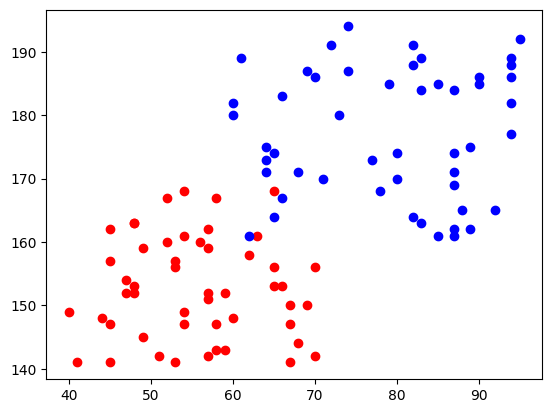

In [164]:
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'o', color='r')
plt.plot([male[0] for male in data[1::2]],
         [male[1] for male in data[1::2]], 'o', color='b')
plt.show()

# 2. 군집화 로직

In [165]:
# 초기 랜덤 지점 2개
random_poinsts = [
    [random.randint(40,90), random.randint(140,195)],
    [random.randint(40,90), random.randint(140,195)]
]
random_poinsts[0], random_poinsts[1]

([64, 161], [79, 185])

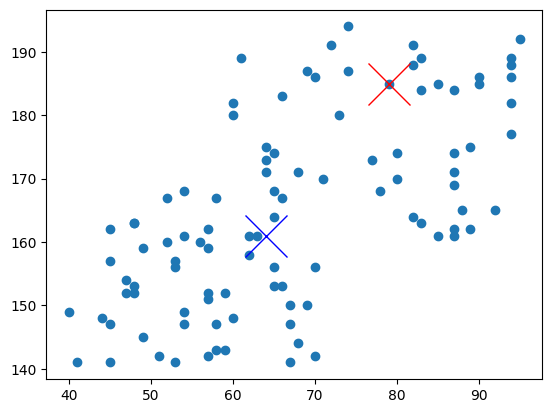

In [166]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b') # 기준점 0
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r') # 기준점 1

In [167]:
# 두점 거리를 return하는 함수 점은 [50,160]
def dist(a, b):
    return np.sqrt( (a[0]-b[0])**2 + (a[1]-b[1])**2 )
print(dist([3,4], [0,0]))
print(dist([5,7], [-1,-1]))

5.0
10.0


In [168]:
# random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0 = []
group1 = []
for d in data:
    if dist(random_poinsts[0], d) < dist(random_poinsts[1], d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(67, 33)

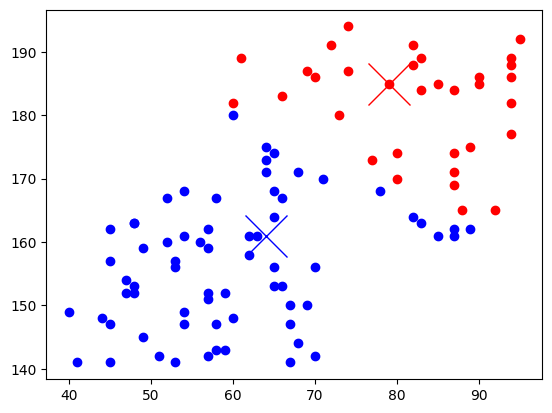

In [169]:
# group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()

In [170]:
# group0과 group1 중심점으로 기준점을 이동
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_poinsts[0] = [group0_meanX, group0_meanY]

group1_meanX = np.mean([d[0] for d in group1])
group1_meanY = np.mean([d[1] for d in group1])
random_poinsts[1] = [group1_meanX, group1_meanY]
random_poinsts

[[59.940298507462686, 156.50746268656715], [82.18181818181819, 182.0]]

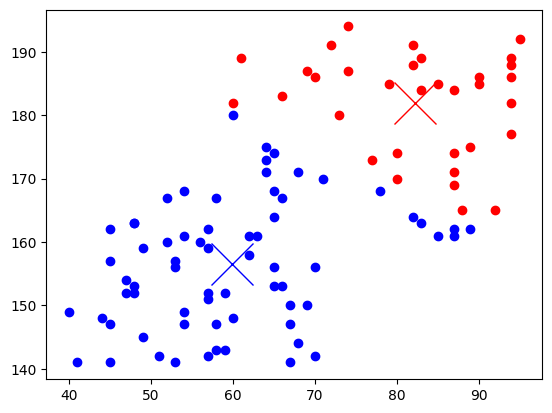

In [171]:
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()

# 3. 군집화 전체 코드(for문 이용)
- 랜덤포인트 2개 지정 - 출력및 시각화
- for문 
    * 랜덤포인트 2지점 기준으로 group0과 group1을 나눔
    * group0의 중간점과 group1의 중간지점을 랜덤포인트로 업데이트
    * 랜덤포인트 출력 및 시각화

초기 지점 : [[58, 159], [51, 180]]
1 번째 points : [[63.75675675675676, 157.82432432432432], [77.3076923076923, 185.1153846153846]]
2 번째 points : [[59.59375, 155.671875], [80.94444444444444, 181.36111111111111]]
3 번째 points : [[56.30909090909091, 154.0909090909091], [80.68888888888888, 178.15555555555557]]
4 번째 points : [[56.0188679245283, 153.41509433962264], [79.97872340425532, 177.89361702127658]]
5 번째 points : [[56.0188679245283, 153.41509433962264], [79.97872340425532, 177.89361702127658]]
6 번째 points : [[56.0188679245283, 153.41509433962264], [79.97872340425532, 177.89361702127658]]
7 번째 points : [[56.0188679245283, 153.41509433962264], [79.97872340425532, 177.89361702127658]]
8 번째 points : [[56.0188679245283, 153.41509433962264], [79.97872340425532, 177.89361702127658]]
9 번째 points : [[56.0188679245283, 153.41509433962264], [79.97872340425532, 177.89361702127658]]
10 번째 points : [[56.0188679245283, 153.41509433962264], [79.97872340425532, 177.89361702127658]]


(40.0, 95.0)

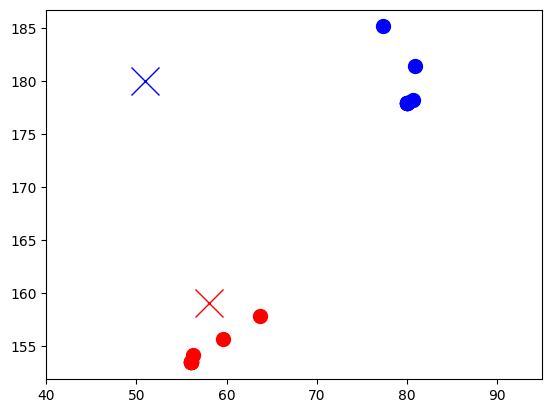

In [181]:
points = [
    [random.randint(40,95), random.randint(140,195)],
    [random.randint(40,95), random.randint(140,195)],
]
print('초기 지점 :', points)
plt.plot(points[0][0], points[0][1], 'x', color='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'x', color='b', markersize=20)
for i in range(1, 11):
    # points 두 지점을 기준으로 group0과 group1 나누기
    group0 = []
    group1 = []
    for info in data:
        if dist(points[0], info) < dist(points[1], info):
            group0.append(info)
        else:
            group1.append(info)
    # group0의 중간점, group1의 중간점으로 points업데이트
    meanX = np.mean([g[0] for g in group0])
    meanY = np.mean([g[1] for g in group0])
    points[0] = [meanX, meanY]
    
    meanX = np.mean([g[0] for g in group1])
    meanY = np.mean([g[1] for g in group1])
    points[1] = [meanX, meanY]
    # 업데이트된 points 출력 및 시각화
    print(i, '번째 points :', points)
    plt.plot(points[0][0], points[0][1], 'o', color='r', markersize=10)
    plt.plot(points[1][0], points[1][1], 'o', color='b', markersize=10)
plt.xlim([40,95])

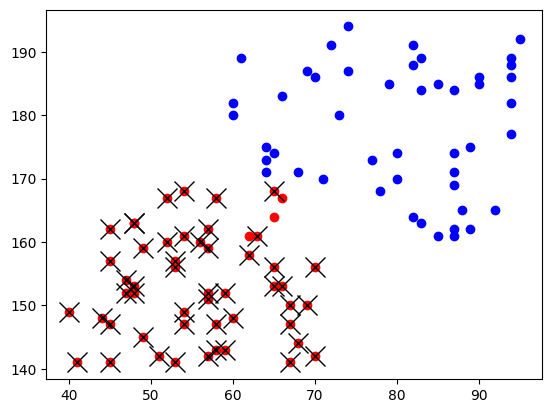

In [186]:
plt.plot([g[0] for g in group0],
         [g[1] for g in group0], 'o', color='r')
plt.plot([g[0] for g in group1],
         [g[1] for g in group1], 'o', color='b')
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'x', color='k', markersize=15)

# 4.api(sklearn)를 이용한 군집화
- sklearn : 머신러닝 패키지
    * 예측/군집모델 : 회귀분석, 분류분석, 군집분석 - fit(학슴), predict(예측,분류)
    * 변환모델 : 전처리시 사용 ex.인코딩, 스케일조정... -fit(학습), transform(변환함수),fit_transform(학변)

In [ ]:
# import os
# os.environ['OMP_NUM_THREADS'] = '1'
# import warnings
# warnings.fiterwarnings(action='ignore') # 경고 무시

In [188]:
from sklearn.cluster import KMeans
data = np.array(data) # 원칙적으로 머신러닝 모델엔 넘파이 배열로 학습
model = KMeans(n_clusters=2,  # 2개 그룹으로 군집화
               init='random', # 초기포인트를 random하게
               n_init=10,     # 10번 실행
               random_state=7)# 일관적인 모댈을 생성하기 위한 seed값
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [189]:
# 두 그룹의 기준점 : [[56.0188679245283, 153.41509433962264], [79.97872340425532, 177.89361702127658]]
model.cluster_centers_

array([[ 79.9787234 , 177.89361702],
       [ 56.01886792, 153.41509434]])

In [190]:
# 나눠진 그룹들의 인덱스
model.labels_

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0])

In [191]:
group1 = data[model.labels_==1]
group0 = data[model.labels_==0]

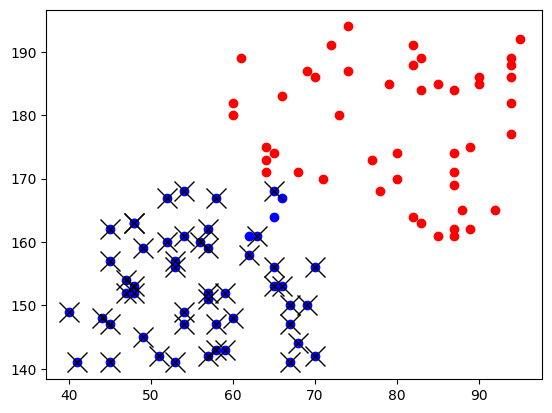

In [192]:
plt.plot([g[0] for g in group0],
         [g[1] for g in group0], 'o', color='r')
plt.plot([g[0] for g in group1],
         [g[1] for g in group1], 'o', color='b')
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]] , 'x', color='k', markersize=15)
plt.show()